CNN-Based Computer Vision Project

Defect Detection in Manufacturing with CNN
This initiative employs a Convolutional Neural Network (CNN) for classifying images of manufactured products into various defect classes.

The categories include:

normal

scratch

dent

stain

In [55]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

Task 1: Problem Definition
Task Type: Image Classification
Each image in this dataset corresponds to precisely one class, making it an image classification problem.

The CNN classifies manufacturing product images as:

normal

scratch

dent

stain

No data for:

bounding boxes

segmentation masks

This confirms image classification as the right computer vision approach.

In [56]:
dataset_path = "dataset/images"

Task 2: Dataset Analysis
This dataset includes manufacturing product images organized across four categories.

The analysis covers:

Class count

Images in each class

Example images

Image sizes

Class distribution balance

In [57]:
img_size = (128, 128)
batch_size = 32

from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 384 images belonging to 4 classes.
Found 96 images belonging to 4 classes.


In [58]:
print(train_data.class_indices)

{'dent': 0, 'normal': 1, 'scratch': 2, 'stain': 3}


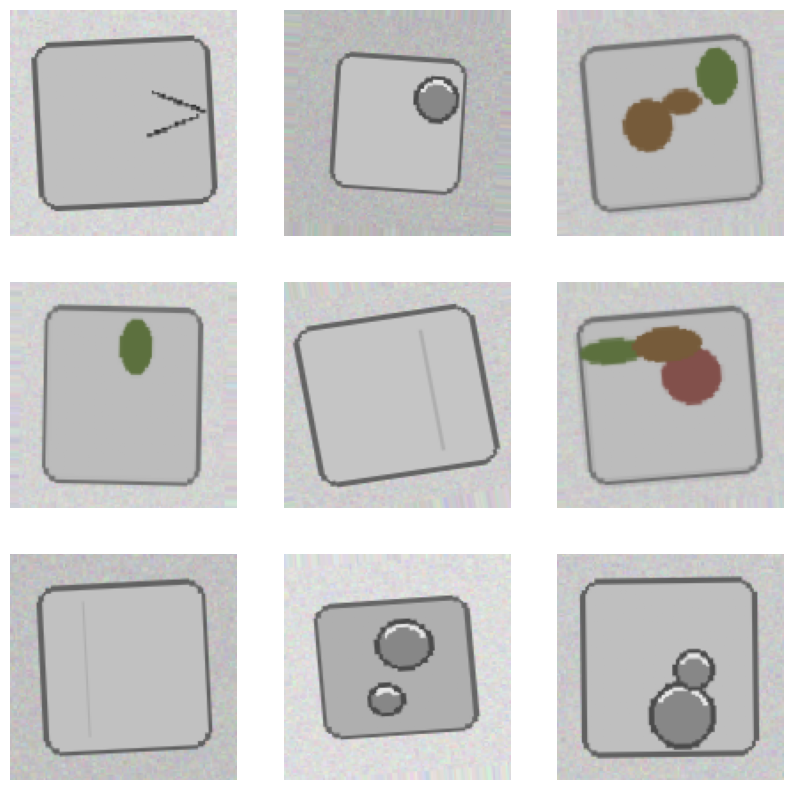

In [59]:
images, labels = next(train_data)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.show()

## Dataset Statistics

Total Classes: 4

### Class Distribution
- normal: 120 images
- scratch: 120 images
- dent: 120 images
- stain: 120 images

### Total Images
480 images

### Image Dimensions
Original Image Size: 96 × 96 × 3

Model Input Size After Preprocessing: 128 × 128 × 3

### Dataset Balance
All classes contain identical image counts, making the dataset perfectly balanced

Task 3: Data Preprocessing Pipeline
Applied preprocessing techniques:

Image Resizing
Uniformly resized all images to 128x128 pixels.

Pixel Normalization
Scaled pixel values with:

rescale = 1./255

Train-Validation Split
Divided dataset into:

80% for training

20% for validation

Augmentation Methods
Used transformations:

Rotation

Zoom

Horizontal flip

These methods boost model robustness and mitigate overfitting

In [60]:
class_counts = train_data.classes

unique, counts = np.unique(class_counts, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Class {u}: {c} images")

Class 0: 96 images
Class 1: 96 images
Class 2: 96 images
Class 3: 96 images


Task 4: CNN Architecture Design
Developed a Convolutional Neural Network (CNN) with TensorFlow/Keras.

Key components include:

Conv layers

ReLU activations

MaxPooling operations

Flatten layer

Fully connected (Dense) layers

Softmax classifier layer

In [61]:
from tensorflow.keras import models, layers

model = models.Sequential([

    # Input Layer
    layers.Input(shape=(128,128,3)),

    # First Convolution Layer
    layers.Conv2D(32, (3,3), activation='relu'),

    # Pooling Layer
    layers.MaxPooling2D((2,2)),

    # Second Convolution Layer
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Third Convolution Layer
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Flatten Layer
    layers.Flatten(),

    # Dense Layer
    layers.Dense(128, activation='relu'),

    # Output Layer
    layers.Dense(4, activation='softmax')
])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [62]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Task 5: Model Training & Evaluation
The CNN model was trained with:

Adam optimizer

Categorical Crossentropy loss function

Accuracy metric

Performance evaluation included:

Training accuracy

Validation accuracy

Confusion matrix

Classification report

Sample predictions

In [63]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 770ms/step - accuracy: 0.2396 - loss: 1.6237 - val_accuracy: 0.2500 - val_loss: 1.3815
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 625ms/step - accuracy: 0.3073 - loss: 1.3756 - val_accuracy: 0.4375 - val_loss: 1.3659
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 549ms/step - accuracy: 0.3906 - loss: 1.3219 - val_accuracy: 0.4896 - val_loss: 1.1876
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 604ms/step - accuracy: 0.5312 - loss: 1.0994 - val_accuracy: 0.5000 - val_loss: 1.0927
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 578ms/step - accuracy: 0.6276 - loss: 0.8937 - val_accuracy: 0.5938 - val_loss: 0.8570
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 585ms/step - accuracy: 0.7240 - loss: 0.6697 - val_accuracy: 0.8542 - val_loss: 0.5356
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 596ms/step - accuracy: 0.8281 - loss: 0.4230 - val_accuracy: 0.8438 - val_loss: 0.3672
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 626ms/step - accuracy: 0.9010 - loss: 0.2768 - val_accuracy: 

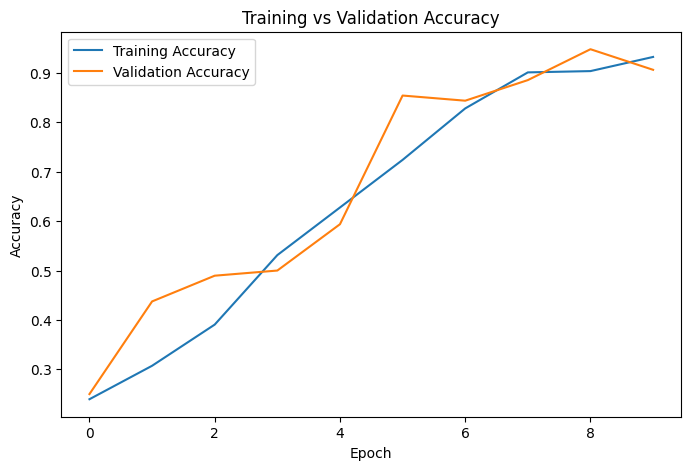

In [64]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()

plt.savefig("results/accuracy_loss_curves.png")

plt.show()

In [65]:
predictions = model.predict(val_data)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = val_data.classes

class_labels = list(val_data.class_indices.keys())

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 263ms/step


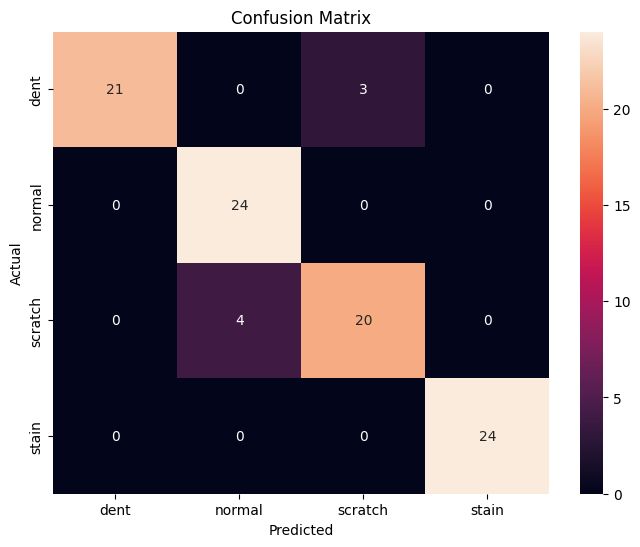

In [66]:
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("results/confusion_matrix.png")

plt.show()

In [67]:
print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
))

              precision    recall  f1-score   support

        dent       1.00      0.88      0.93        24
      normal       0.86      1.00      0.92        24
     scratch       0.87      0.83      0.85        24
       stain       1.00      1.00      1.00        24

    accuracy                           0.93        96
   macro avg       0.93      0.93      0.93        96
weighted avg       0.93      0.93      0.93        96



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step


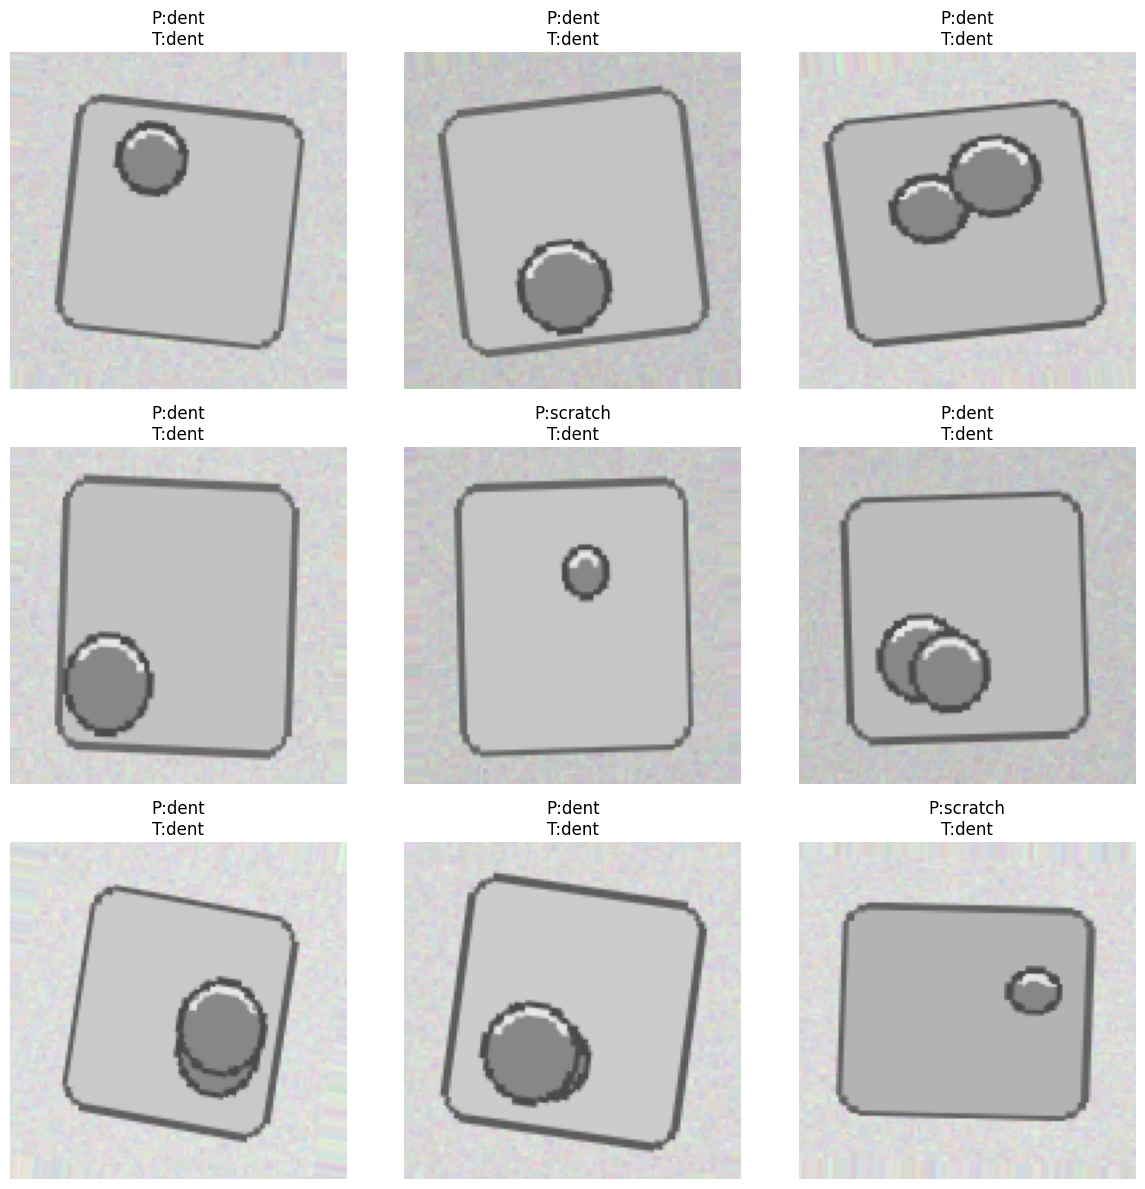

In [68]:
images, labels = next(val_data)

preds = model.predict(images)

plt.figure(figsize=(12,12))

for i in range(9):
    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    pred_label = class_labels[np.argmax(preds[i])]
    true_label = class_labels[np.argmax(labels[i])]

    plt.title(f"P:{pred_label}\nT:{true_label}")

    plt.axis("off")

plt.tight_layout()

plt.savefig("sample_predictions/prediction_outputs.png")

plt.show()

Conclusion
A successful CNN-based image classification system was developed for detecting manufacturing defects.

The model extracted visual features from product images through:

Convolution operations

ReLU activation

Pooling layers

Dense layers

The system automatically identifies:

normal

scratch

dent

stain

This solution enables automated quality control in manufacturing